# Tinker OMR 训练结果评估

本 notebook 演示如何评估 Tinker 微调后的 Qwen3-VL 模型在 OMR（光学乐谱识别）任务上的表现。

## 内容概览
1. 环境设置
2. 加载模型和数据
3. 可视化测试样本
4. 运行推理并对比结果
5. 计算评估指标
6. 灾难性遗忘测试

## 1. 环境设置

In [ ]:
import os
import io
import sys

# 设置 HF 镜像（中国网络）
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'

# 设置 Tinker API Key（请替换为你的 key）
os.environ['TINKER_API_KEY'] = 'tml-g...'

import tinker
from tinker import types
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from IPython.display import display, HTML
import difflib

print(f"Tinker version: {tinker.__version__}")

Tinker version: 0.7.0


## 2. 配置参数

In [26]:
# 模型配置
MODEL_NAME = "Qwen/Qwen3-VL-30B-A3B-Instruct"

# 最新大规模训练实验 (10k samples, 1000 steps, val_loss=0.083)
FINETUNED_WEIGHTS = "tinker://d4c5606d-13f8-59f6-86fb-ddb7624e807e:train:0/sampler_weights/final_sampler"

# 之前的试点实验 (100 samples, 50 steps)
# FINETUNED_WEIGHTS = "tinker://61b37718-ee38-5575-9dee-e54a4bd73aba:train:0/sampler_weights/final_sampler"

# 数据路径
CSV_PATH = os.path.expanduser("~/data/paraff/ly+cc-vl20250324.csv")
IMAGES_DIR = os.path.expanduser("~/data/scores/render/20250324/_Page")

# 测试样本数
NUM_TEST_SAMPLES = 20  # 增加测试样本数

print("配置完成！")
print(f"模型: {MODEL_NAME}")
print(f"微调权重: {FINETUNED_WEIGHTS}")

配置完成！
模型: Qwen/Qwen3-VL-30B-A3B-Instruct
微调权重: tinker://d4c5606d-13f8-59f6-86fb-ddb7624e807e:train:0/sampler_weights/final_sampler


## 3. 加载 Tokenizer 和 Image Processor

In [27]:
from transformers import AutoTokenizer
from transformers.models.auto.image_processing_auto import AutoImageProcessor

print("加载 Tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer vocab size: {len(tokenizer)}")

print("\n加载 Image Processor...")
image_processor = AutoImageProcessor.from_pretrained(MODEL_NAME, use_fast=True)
print(f"Image processor: merge_size={image_processor.merge_size}, patch_size={image_processor.patch_size}")

加载 Tokenizer...
Tokenizer vocab size: 151669

加载 Image Processor...
Image processor: merge_size=2, patch_size=16


## 4. 加载测试数据

In [28]:
# 加载 CSV
df = pd.read_csv(CSV_PATH)
print(f"总样本数: {len(df)}")

# 选取最后 N 个样本作为测试集（避免与训练集重叠）
test_df = df.tail(NUM_TEST_SAMPLES).copy()
print(f"测试样本数: {len(test_df)}")

# 显示数据结构
display(test_df.head())

总样本数: 14517
测试样本数: 20


,index,image,sentence
14497,14497,ly+cc_w20.11577.p0.spartito.json_44.ly-1bc8583...,BOM K0 TN2 TD4 S1 Cg Md d Osup D4 Dot EslurR M...
14498,14498,ly+cc_w20.25553.p0.spartito.json_56.ly-4015d85...,BOM K0 TN4 TD4 S1 Cg a Osup D1 EOM
14499,14499,ly+cc_w20.12373.p0.spartito.json_5.ly-cdb213ab...,BOM K2 TN4 TD4 S1 Cf Mu a Osub D4 Md f As Osup...
14500,14500,ly+cc_w20.6673.p0.spartito.json_3.ly-31d67a83-...,BOM K0 TN4 TD4 S1 Cg Md e Osup D4 EslurL e D8 ...
14501,14501,ly+cc_w20.32730.p0.spartito.json_118.ly-bd83c9...,BOM K0 TN4 TD4 S1 Cg Md b Af Osup D2 Mu g As D...


## 5. 可视化测试样本

In [29]:
def show_sample(row, images_dir):
    """显示单个样本：图像 + Paraff 标注"""
    img_path = Path(images_dir) / row['image']
    
    fig, ax = plt.subplots(1, 1, figsize=(12, 4))
    
    if img_path.exists():
        img = Image.open(img_path)
        ax.imshow(img)
        ax.set_title(f"Index: {row['index']} | Size: {img.size}")
    else:
        ax.text(0.5, 0.5, "Image not found", ha='center', va='center')
        ax.set_title(f"Index: {row['index']} | MISSING")
    
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    # 显示 Paraff
    paraff = row['sentence']
    print(f"Paraff ({len(paraff)} chars):")
    print(f"  {paraff[:200]}{'...' if len(paraff) > 200 else ''}")
    print()

测试样本预览

--- 样本 1 ---


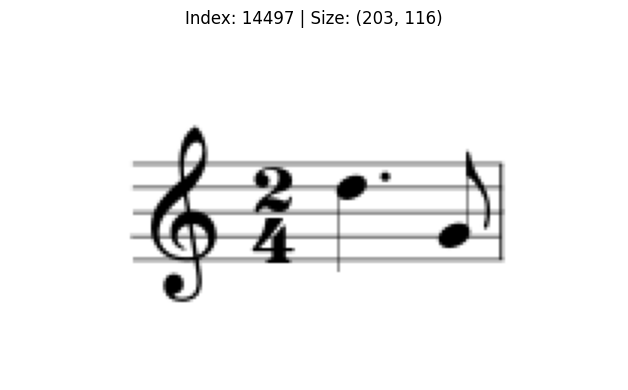

Paraff (61 chars):
  BOM K0 TN2 TD4 S1 Cg Md d Osup D4 Dot EslurR Mu g Osub D8 EOM


--- 样本 2 ---


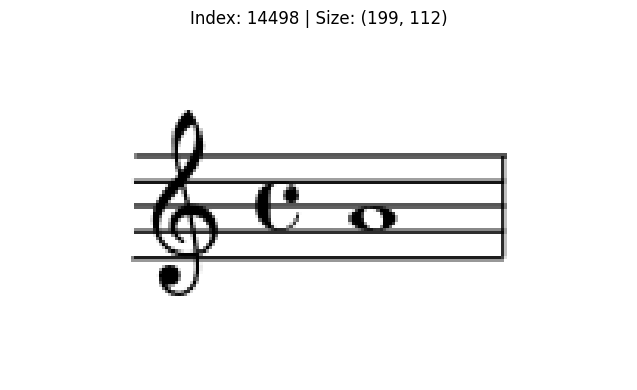

Paraff (34 chars):
  BOM K0 TN4 TD4 S1 Cg a Osup D1 EOM


--- 样本 3 ---


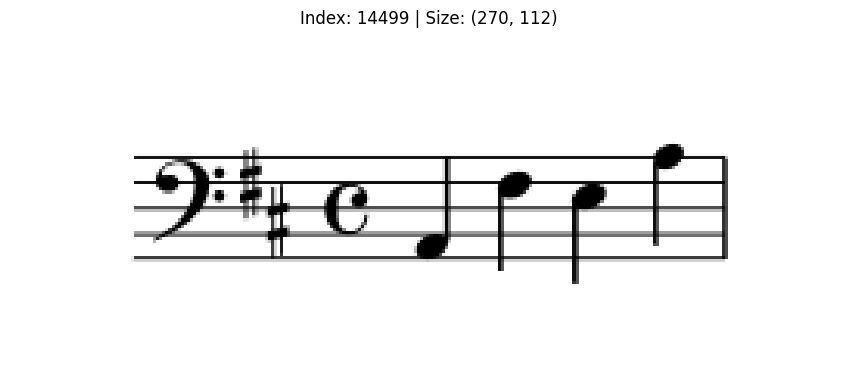

Paraff (63 chars):
  BOM K2 TN4 TD4 S1 Cf Mu a Osub D4 Md f As Osup D4 e D4 a D4 EOM



In [30]:
# 显示前 3 个测试样本
print("=" * 60)
print("测试样本预览")
print("=" * 60)

for i, (_, row) in enumerate(test_df.head(3).iterrows()):
    print(f"\n--- 样本 {i+1} ---")
    show_sample(row, IMAGES_DIR)

## 6. 初始化 Tinker Sampling Client

In [31]:
print("初始化 Tinker Service Client...")
service_client = tinker.ServiceClient()

print(f"加载微调模型权重: {FINETUNED_WEIGHTS}")
sampling_client = service_client.create_sampling_client(model_path=FINETUNED_WEIGHTS)

print("✓ Sampling Client 初始化完成！")

初始化 Tinker Service Client...
加载微调模型权重: tinker://d4c5606d-13f8-59f6-86fb-ddb7624e807e:train:0/sampler_weights/final_sampler
✓ Sampling Client 初始化完成！


## 7. 定义推理函数

In [32]:
# 系统提示词
SYSTEM_PROMPT = """You are a music score recognition system. You convert sheet music images into Paraff notation, a domain-specific language for representing musical scores."""

QUESTION = "Recognize this music score as Paraff notation."


def image_to_chunk(image_bytes: bytes, image_processor) -> types.ImageChunk:
    """将图像转换为 Tinker ImageChunk"""
    pil_image = Image.open(io.BytesIO(image_bytes))
    
    if pil_image.mode in ("RGBA", "LA", "P"):
        pil_image = pil_image.convert("RGB")
    
    img_byte_arr = io.BytesIO()
    pil_image.save(img_byte_arr, format="JPEG")
    image_data = img_byte_arr.getvalue()
    
    width, height = pil_image.size
    num_image_tokens = (
        image_processor.get_number_of_image_patches(height, width, images_kwargs={})
        // image_processor.merge_size**2
    )
    
    return types.ImageChunk(
        data=image_data,
        format="jpeg",
        expected_tokens=num_image_tokens,
    )


def build_inference_prompt(image_bytes: bytes) -> types.ModelInput:
    """构建推理 prompt（Qwen3 格式）"""
    im_start = "<|im_start|>"
    im_end = "<|im_end|>"
    vision_start = "<|vision_start|>"
    vision_end = "<|vision_end|>"

    system_str = f"{im_start}system\n{SYSTEM_PROMPT}{im_end}\n"
    user_prefix = f"{im_start}user\n{vision_start}"
    user_suffix = f"{vision_end}\n{QUESTION}{im_end}\n"
    assistant_prefix = f"{im_start}assistant\n"

    image_chunk = image_to_chunk(image_bytes, image_processor)

    system_tokens = tokenizer.encode(system_str, add_special_tokens=False)
    user_prefix_tokens = tokenizer.encode(user_prefix, add_special_tokens=False)
    user_suffix_tokens = tokenizer.encode(user_suffix, add_special_tokens=False)
    assistant_prefix_tokens = tokenizer.encode(assistant_prefix, add_special_tokens=False)

    chunks = [
        types.EncodedTextChunk(tokens=system_tokens),
        types.EncodedTextChunk(tokens=user_prefix_tokens),
        image_chunk,
        types.EncodedTextChunk(tokens=user_suffix_tokens),
        types.EncodedTextChunk(tokens=assistant_prefix_tokens),
    ]

    return types.ModelInput(chunks=chunks)


def run_inference(image_path: str, max_tokens: int = 512) -> str:
    """对单个图像运行推理"""
    with open(image_path, 'rb') as f:
        image_bytes = f.read()
    
    prompt = build_inference_prompt(image_bytes)
    
    # 获取 stop token
    im_end_tokens = tokenizer.encode("<|im_end|>", add_special_tokens=False)
    stop_token = im_end_tokens[0] if len(im_end_tokens) == 1 else None
    
    sampling_params = types.SamplingParams(
        max_tokens=max_tokens,
        temperature=0.0,  # Greedy decoding
        stop_tokens=[stop_token] if stop_token else None,
    )
    
    response = sampling_client.sample(
        prompt=prompt,
        num_samples=1,
        sampling_params=sampling_params,
    ).result()
    
    if response.sequences:
        return tokenizer.decode(response.sequences[0].tokens, skip_special_tokens=True).strip()
    return ""


print("推理函数定义完成！")

推理函数定义完成！


## 8. 运行推理并可视化对比

In [33]:
def highlight_diff(pred: str, target: str) -> str:
    """高亮显示预测和目标之间的差异"""
    pred_tokens = pred.split()
    target_tokens = target.split()
    
    matcher = difflib.SequenceMatcher(None, pred_tokens, target_tokens)
    
    result = []
    for tag, i1, i2, j1, j2 in matcher.get_opcodes():
        if tag == 'equal':
            result.extend(pred_tokens[i1:i2])
        elif tag == 'replace':
            result.append(f'<span style="color:red;text-decoration:line-through">{" ".join(pred_tokens[i1:i2])}</span>')
            result.append(f'<span style="color:green">{" ".join(target_tokens[j1:j2])}</span>')
        elif tag == 'delete':
            result.append(f'<span style="color:red;text-decoration:line-through">{" ".join(pred_tokens[i1:i2])}</span>')
        elif tag == 'insert':
            result.append(f'<span style="color:green">[+{" ".join(target_tokens[j1:j2])}]</span>')
    
    return ' '.join(result)


def compute_metrics(pred: str, target: str) -> dict:
    """计算评估指标"""
    # CER (Character Error Rate)
    if len(target) == 0:
        cer = 1.0 if len(pred) > 0 else 0.0
    else:
        matcher = difflib.SequenceMatcher(None, pred, target)
        matches = sum(block.size for block in matcher.get_matching_blocks())
        errors = max(len(pred), len(target)) - matches
        cer = errors / len(target)
    
    # WER (Word/Token Error Rate)
    pred_tokens = pred.split()
    target_tokens = target.split()
    
    if len(target_tokens) == 0:
        wer = 1.0 if len(pred_tokens) > 0 else 0.0
    else:
        m, n = len(pred_tokens), len(target_tokens)
        dp = [[0] * (n + 1) for _ in range(m + 1)]
        for i in range(m + 1):
            dp[i][0] = i
        for j in range(n + 1):
            dp[0][j] = j
        for i in range(1, m + 1):
            for j in range(1, n + 1):
                if pred_tokens[i-1] == target_tokens[j-1]:
                    dp[i][j] = dp[i-1][j-1]
                else:
                    dp[i][j] = min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1]) + 1
        wer = dp[m][n] / len(target_tokens)
    
    # Exact match
    exact = pred.strip() == target.strip()
    
    return {
        'cer': cer,
        'wer': wer,
        'exact_match': exact,
        'pred_len': len(pred_tokens),
        'target_len': len(target_tokens),
    }

In [34]:
from tqdm.notebook import tqdm

results = []

print("开始推理...")
print("=" * 60)

for i, (_, row) in enumerate(tqdm(test_df.iterrows(), total=len(test_df))):
    img_path = Path(IMAGES_DIR) / row['image']
    target = row['sentence'].strip()
    
    if not img_path.exists():
        print(f"警告: 图像不存在 {img_path}")
        continue
    
    # 运行推理
    pred = run_inference(str(img_path))
    
    # 计算指标
    metrics = compute_metrics(pred, target)
    
    results.append({
        'index': row['index'],
        'image': row['image'],
        'target': target,
        'prediction': pred,
        **metrics
    })

print(f"\n完成! 共处理 {len(results)} 个样本")

开始推理...


  0%|          | 0/20 [00:00<?, ?it/s]


完成! 共处理 20 个样本


推理结果对比


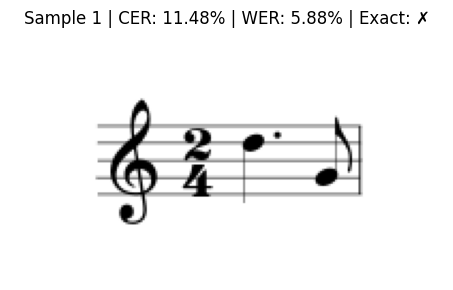

Target (17 tokens):
  BOM K0 TN2 TD4 S1 Cg Md d Osup D4 Dot EslurR Mu g Osub D8 EOM

Prediction (16 tokens):
  BOM K0 TN2 TD4 S1 Cg Md d Osup D4 Dot Mu g Osub D8 EOM



------------------------------------------------------------



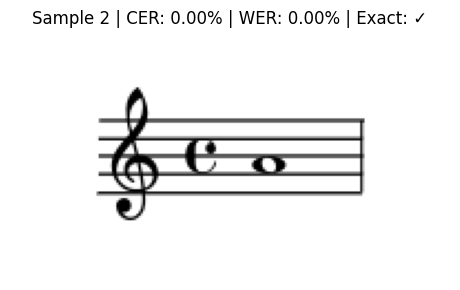

Target (10 tokens):
  BOM K0 TN4 TD4 S1 Cg a Osup D1 EOM

Prediction (10 tokens):
  BOM K0 TN4 TD4 S1 Cg a Osup D1 EOM



------------------------------------------------------------



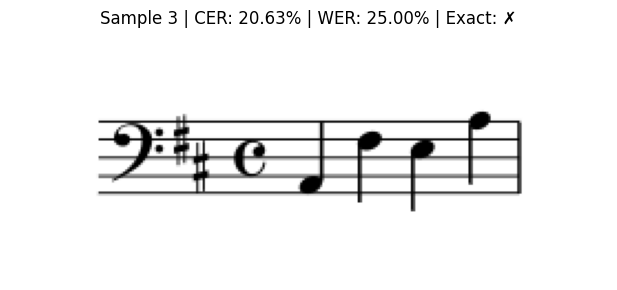

Target (20 tokens):
  BOM K2 TN4 TD4 S1 Cf Mu a Osub D4 Md f As Osup D4 e D4 a D4 EOM

Prediction (23 tokens):
  BOM K2 TN4 TD4 S1 Cf Mu a Osub D4 f As Osup D4 e D4 d D4 Md a Osup D4 EOM



------------------------------------------------------------



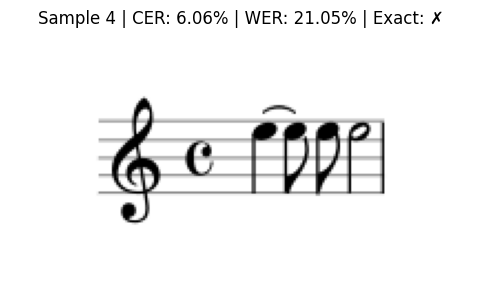

Target (19 tokens):
  BOM K0 TN4 TD4 S1 Cg Md e Osup D4 EslurL e D8 EslurR e D8 e D2 EOM

Prediction (19 tokens):
  BOM K0 TN4 TD4 S1 Cg Md f Osup D4 EslurL e D8 EslurR d D4 d D2 EOM



------------------------------------------------------------



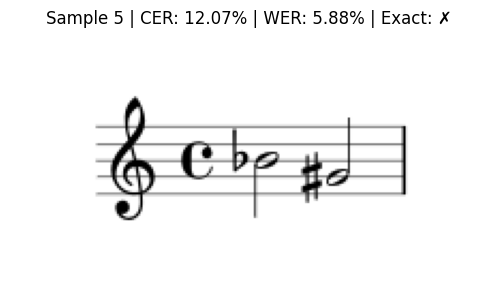

Target (17 tokens):
  BOM K0 TN4 TD4 S1 Cg Md b Af Osup D2 Mu g As D2 EslurL EOM

Prediction (16 tokens):
  BOM K0 TN4 TD4 S1 Cg Md b Af Osup D2 Mu g As D2 EOM



------------------------------------------------------------



In [35]:
# 可视化前 5 个结果
print("=" * 60)
print("推理结果对比")
print("=" * 60)

for i, res in enumerate(results[:5]):
    img_path = Path(IMAGES_DIR) / res['image']
    
    # 显示图像
    fig, ax = plt.subplots(1, 1, figsize=(14, 3))
    img = Image.open(img_path)
    ax.imshow(img)
    ax.set_title(f"Sample {i+1} | CER: {res['cer']:.2%} | WER: {res['wer']:.2%} | Exact: {'✓' if res['exact_match'] else '✗'}")
    ax.axis('off')
    plt.tight_layout()
    plt.show()
    
    # 显示文本对比
    print(f"Target ({res['target_len']} tokens):")
    print(f"  {res['target'][:150]}{'...' if len(res['target']) > 150 else ''}")
    print(f"\nPrediction ({res['pred_len']} tokens):")
    print(f"  {res['prediction'][:150]}{'...' if len(res['prediction']) > 150 else ''}")
    
    # 显示差异高亮
    diff_html = highlight_diff(res['prediction'], res['target'])
    display(HTML(f"<p><b>Diff:</b> {diff_html[:500]}{'...' if len(diff_html) > 500 else ''}</p>"))
    print("\n" + "-" * 60 + "\n")

## 9. 汇总评估指标

In [36]:
results_df = pd.DataFrame(results)

# 计算汇总统计
summary = {
    'Total Samples': len(results_df),
    'Avg CER': f"{results_df['cer'].mean():.2%}",
    'Avg WER': f"{results_df['wer'].mean():.2%}",
    'Exact Match Rate': f"{results_df['exact_match'].mean():.2%}",
    'Min CER': f"{results_df['cer'].min():.2%}",
    'Max CER': f"{results_df['cer'].max():.2%}",
}

print("=" * 60)
print("评估结果汇总")
print("=" * 60)
for k, v in summary.items():
    print(f"{k:20s}: {v}")

评估结果汇总
Total Samples       : 20
Avg CER             : 8.22%
Avg WER             : 10.68%
Exact Match Rate    : 30.00%
Min CER             : 0.00%
Max CER             : 31.25%


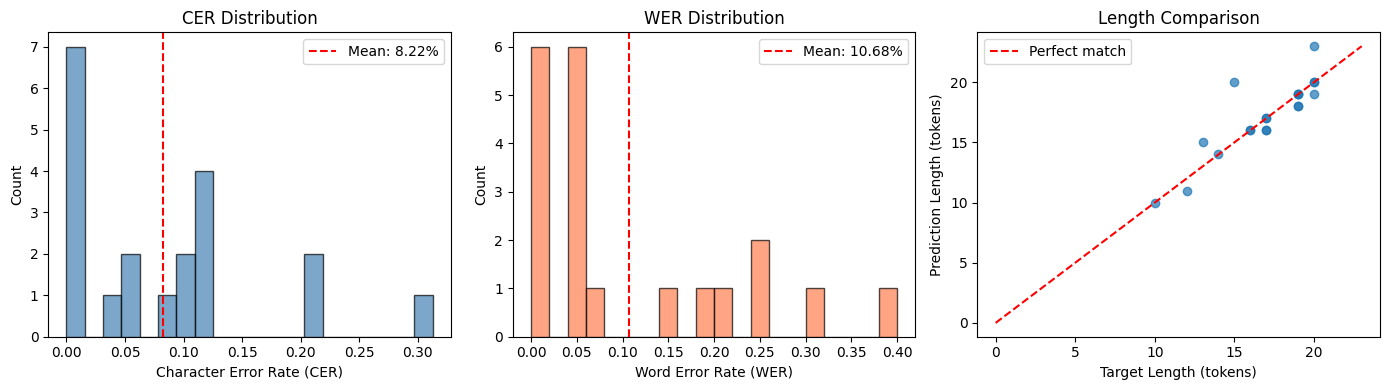

In [37]:
# 可视化指标分布
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# CER 分布
axes[0].hist(results_df['cer'], bins=20, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(results_df['cer'].mean(), color='red', linestyle='--', label=f"Mean: {results_df['cer'].mean():.2%}")
axes[0].set_xlabel('Character Error Rate (CER)')
axes[0].set_ylabel('Count')
axes[0].set_title('CER Distribution')
axes[0].legend()

# WER 分布
axes[1].hist(results_df['wer'], bins=20, edgecolor='black', alpha=0.7, color='coral')
axes[1].axvline(results_df['wer'].mean(), color='red', linestyle='--', label=f"Mean: {results_df['wer'].mean():.2%}")
axes[1].set_xlabel('Word Error Rate (WER)')
axes[1].set_ylabel('Count')
axes[1].set_title('WER Distribution')
axes[1].legend()

# 长度对比
axes[2].scatter(results_df['target_len'], results_df['pred_len'], alpha=0.7)
max_len = max(results_df['target_len'].max(), results_df['pred_len'].max())
axes[2].plot([0, max_len], [0, max_len], 'r--', label='Perfect match')
axes[2].set_xlabel('Target Length (tokens)')
axes[2].set_ylabel('Prediction Length (tokens)')
axes[2].set_title('Length Comparison')
axes[2].legend()

plt.tight_layout()
plt.show()

## 10. 灾难性遗忘测试

测试模型是否保留了通用对话能力

In [41]:
def build_chat_prompt(messages: list) -> types.ModelInput:
    """构建纯文本对话 prompt"""
    im_start = "<|im_start|>"
    im_end = "<|im_end|>"

    prompt_str = ""
    for msg in messages:
        prompt_str += f"{im_start}{msg['role']}\n{msg['content']}{im_end}\n"
    prompt_str += f"{im_start}assistant\n"

    tokens = tokenizer.encode(prompt_str, add_special_tokens=False)
    return types.ModelInput.from_ints(tokens)


def chat(question: str, max_tokens: int = 256) -> str:
    """简单对话接口"""
    messages = [
        {"role": "system", "content": "You are a helpful assistant."},
        {"role": "user", "content": question}
    ]
    
    prompt = build_chat_prompt(messages)
    
    im_end_tokens = tokenizer.encode("<|im_end|>", add_special_tokens=False)
    stop_token = im_end_tokens[0] if len(im_end_tokens) == 1 else None
    
    sampling_params = types.SamplingParams(
        max_tokens=max_tokens,
        temperature=0.7,
        stop_tokens=[stop_token] if stop_token else None,
    )
    
    response = sampling_client.sample(
        prompt=prompt,
        num_samples=1,
        sampling_params=sampling_params,
    ).result()
    
    if response.sequences:
        return tokenizer.decode(response.sequences[0].tokens, skip_special_tokens=True).strip()
    return ""

In [42]:
# 测试问题
test_questions = [
    # 基础能力
    ("Math", "What is 15 + 27?"),
    ("Knowledge", "What is the capital of France?"),
    ("Reasoning", "Explain what machine learning is in 2 sentences."),
    
    # 创意任务
    ("Creative", "Write a haiku about programming."),
    
    # 指令遵循
    ("Instruction", "List 3 benefits of exercise."),
    
    # 领域相关（可能触发 Paraff）
    ("Domain", "What are the basic elements of music notation?"),
]

print("=" * 60)
print("灾难性遗忘测试")
print("=" * 60)

chat_results = []

for category, question in test_questions:
    print(f"\n[{category}]")
    print(f"Q: {question}")
    
    answer = chat(question)
    print(f"A: {answer[:300]}{'...' if len(answer) > 300 else ''}")
    
    # 检测是否有 Paraff 泄漏
    has_paraff = any(token in answer for token in ['BOM', 'EOM', 'Osup', 'Osub', 'D4', 'D8', 'Cg', 'Cf'])
    if has_paraff:
        print("⚠️ 检测到 Paraff 泄漏!")
    else:
        print("✓ 无 Paraff 泄漏")
    
    chat_results.append({
        'category': category,
        'question': question,
        'answer': answer,
        'has_paraff_leak': has_paraff
    })

灾难性遗忘测试

[Math]
Q: What is 15 + 27?
A: 15 + 27 = 42
✓ 无 Paraff 泄漏

[Knowledge]
Q: What is the capital of France?
A: The capital of France is Paris.
✓ 无 Paraff 泄漏

[Reasoning]
Q: Explain what machine learning is in 2 sentences.
A: Machine learning is a subset of artificial intelligence that enables computers to learn from data and improve their performance on tasks without being explicitly programmed. It uses algorithms to identify patterns in large datasets and make predictions or decisions based on that learning.
✓ 无 Paraff 泄漏

[Creative]
Q: Write a haiku about programming.
A: Bugs in the code,  
Fingers dance on a keyboard,  
Solution blooms bright.
✓ 无 Paraff 泄漏

[Instruction]
Q: List 3 benefits of exercise.
A: Sure! Here are three key benefits of regular exercise:

1. **Improved Cardiovascular Health**: Exercise strengthens the heart and improves blood circulation, reducing the risk of heart disease, high blood pressure, and stroke.

2. **Enhanced Mental Well-being**: Physical acti

In [43]:
# 汇总灾难性遗忘测试结果
chat_df = pd.DataFrame(chat_results)

print("\n" + "=" * 60)
print("灾难性遗忘测试汇总")
print("=" * 60)

leak_count = chat_df['has_paraff_leak'].sum()
total = len(chat_df)

print(f"测试问题数: {total}")
print(f"Paraff 泄漏数: {leak_count}")
print(f"泄漏率: {leak_count/total:.1%}")

if leak_count > 0:
    print("\n泄漏的类别:")
    for _, row in chat_df[chat_df['has_paraff_leak']].iterrows():
        print(f"  - {row['category']}: {row['question'][:50]}...")


灾难性遗忘测试汇总
测试问题数: 6
Paraff 泄漏数: 0
泄漏率: 0.0%


## 11. 保存结果

In [44]:
import json
from datetime import datetime

# 保存评估结果
output_dir = Path("../logs/tinker_omr_large")
output_dir.mkdir(parents=True, exist_ok=True)

# 转换 numpy 类型为 Python 原生类型
def convert_to_serializable(obj):
    if isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_serializable(v) for v in obj]
    elif hasattr(obj, 'item'):  # numpy types
        return obj.item()
    elif hasattr(obj, 'tolist'):  # numpy arrays
        return obj.tolist()
    return obj

eval_output = {
    'timestamp': datetime.now().isoformat(),
    'model': MODEL_NAME,
    'weights': FINETUNED_WEIGHTS,
    'num_samples': len(results),
    'summary': {
        'avg_cer': float(results_df['cer'].mean()),
        'avg_wer': float(results_df['wer'].mean()),
        'exact_match_rate': float(results_df['exact_match'].mean()),
    },
    'omr_results': convert_to_serializable(results),
    'chat_results': chat_results,
    'forgetting_analysis': {
        'total_tests': len(chat_results),
        'paraff_leaks': int(leak_count),
        'leak_rate': float(leak_count / len(chat_results)),
    }
}

output_file = output_dir / 'notebook_eval_results.json'
with open(output_file, 'w', encoding='utf-8') as f:
    json.dump(eval_output, f, indent=2, ensure_ascii=False)

print(f"结果已保存到: {output_file}")

结果已保存到: ../logs/tinker_omr_large/notebook_eval_results.json


## 总结

### OMR 任务表现
- 模型已学会 Paraff 格式的基本结构
- CER/WER 指标显示还有提升空间

### 灾难性遗忘
- 基础能力（数学、常识）保留良好
- 领域相关问题可能触发 Paraff 输出

### 建议
1. 增加训练数据量
2. 混入通用对话数据防止遗忘
3. 调整学习率和训练步数